> ⚠ **Not for production.** Логика портирована в `src/pipeline/enrich_sessions_nlp.py` (порт сверен с артефактом бит-в-бит: 9,031,454 строк, 0 расхождений). Пересборка `intent_sessions_with_query_features.parquet` — через CLI порта, не через этот ноутбук. Ноутбук сохранён как research-обоснование формулы `query_stratification_score`.

# Стратификация трафика (post-stratification)

## 1.1

In [2]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt #понадобится для графиков

In [3]:
SESSIONS = Path('../../data/intent_sessions_full.parquet')
PRODUCTS = Path('../../data/product_information')
df = pl.read_parquet(str(SESSIONS))
products = pl.read_parquet(str(PRODUCTS))

## Гистограмма число уникальных запросов

сначала посмотрим квантили, чтобы понять, где обрезать график:

In [4]:
df.select(
    pl.col("n_unique_queries").quantile(0.90).alias("q90"),
    pl.col("n_unique_queries").quantile(0.95).alias("q95"),
    pl.col("n_unique_queries").quantile(0.99).alias("q99"),
    pl.col("n_unique_queries").max().alias("max"),
)

q90,q95,q99,max
f64,f64,f64,u32
7.0,10.0,19.0,99225


Для визуализации распределения `n_unique_queries` ограничиваем значения `<= 20`,
так как 99% сессий имеют не более 19 уникальных запросов, а максимальное значение
равно 99225 и сильно искажает масштаб графика.

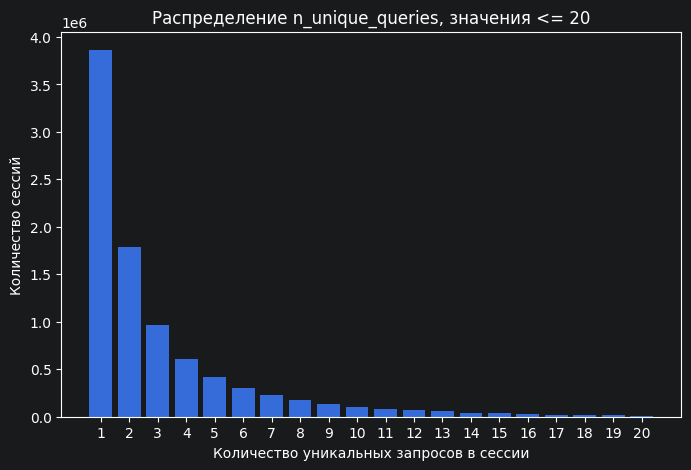

In [5]:
#создаю таблицу количество уникальных запросов/колько сессий имеют такое количество запросов
counts = (
    df
    .filter(pl.col("n_unique_queries") <= 20)#чтобы убрать большие выбросы и сделать график читаемым
    .group_by("n_unique_queries")#группирую по значению
    .len()#считаю количество сессий
    .sort("n_unique_queries")#сортирую чтобы столбцы шли по порядку
)
#создаю область для графика
plt.figure(figsize=(8, 5))
#строю столбчатую диаграмму
plt.bar(
    counts["n_unique_queries"].to_list(),
    counts["len"].to_list()
)

plt.xlabel("Количество уникальных запросов в сессии")
plt.ylabel("Количество сессий")
plt.title("Распределение n_unique_queries, значения <= 20")
plt.xticks(range(1, 21))

plt.show()

### Вывод по графику `n_unique_queries`

Большинство интент-сессий содержат небольшое число уникальных поисковых запросов.
Самое частое значение — `1`: пользователь чаще всего формулирует один запрос в рамках сессии.

Дальше количество сессий быстро убывает: сессий с `2`, `3`, `4` и более уникальными запросами становится всё меньше.
Это означает, что длинные поисковые сценарии встречаются заметно реже.

Для визуализации были показаны только значения `n_unique_queries <= 20`, потому что по квантилям видно:
99% сессий имеют не более 19 уникальных запросов, а максимальное значение сильно больше и искажает масштаб графика.

## Гистограмма длинна поискового запроса

In [6]:
# Создаём нормализованный первый поисковый запрос
# query_clean понадобится для сравнения с базой продуктов и item_id

df = df.with_columns(
    pl.col("first_query")
    .str.to_lowercase()
    .str.replace_all("ё", "е")
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
    .alias("query_clean")
)

# Создаём колонку с длиной первого поискового запроса в словах
# Слово = последовательность символов, отделённая пробелами

df = df.with_columns(
    pl.when(
        pl.col("query_clean").is_null() |
        (pl.col("query_clean") == "")
    )
    .then(0)
    .otherwise(
        pl.col("query_clean")
        .str.split(" ")
        .list.len()
    )
    .alias("query_len_words")
)

сначала посмотрим квантили, чтобы понять, где обрезать график:

In [7]:
df.select(
    pl.col("query_len_words").quantile(0.90).alias("q90"),
    pl.col("query_len_words").quantile(0.95).alias("q95"),
    pl.col("query_len_words").quantile(0.99).alias("q99"),
    pl.col("query_len_words").max().alias("max"),
)

q90,q95,q99,max
f64,f64,f64,u32
4.0,4.0,6.0,122


Для визуализации длины поискового запроса ограничиваем значения `<= 10`,
так как 99% запросов имеют длину не более 6 слов, а максимальное значение равно 122
и может искажать масштаб графика.

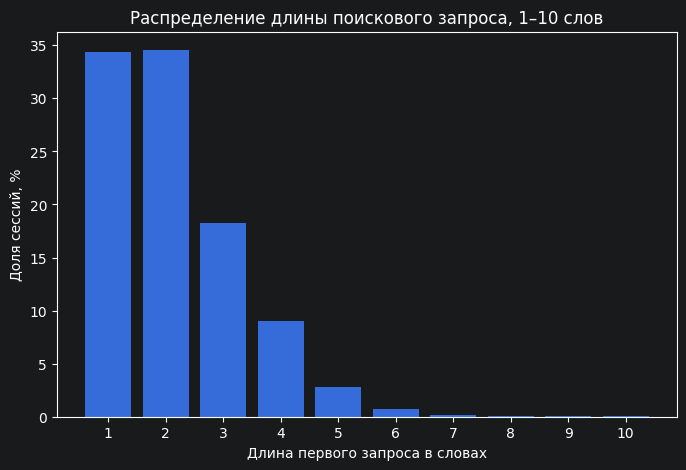

In [8]:
LIMIT = 10

counts_len = (
    df
    .filter(
        (pl.col("query_len_words") >= 1) &
        (pl.col("query_len_words") <= LIMIT)
    )
    .group_by("query_len_words")
    .len()
    .sort("query_len_words")
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100).alias("percent")
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    counts_len["query_len_words"].to_list(),
    counts_len["percent"].to_list()
)

plt.xlabel("Длина первого запроса в словах")
plt.ylabel("Доля сессий, %")
plt.title(f"Распределение длины поискового запроса, 1–{LIMIT} слов")
plt.xticks(range(1, LIMIT + 1))

plt.show()

### Вывод по гистограмме длины поискового запроса

Большинство первых поисковых запросов короткие: чаще всего запрос состоит из 1–2 слов.
Запросы длиной 3 слова встречаются заметно реже, а начиная с 4–5 слов доля таких сессий быстро падает.

Это означает, что пользователи в основном формулируют интент короткими фразами: названием товара, категорией, брендом или их сочетанием.

Для визуализации были исключены нулевые значения, так как они соответствуют пустым или отсутствующим `first_query`. Также график ограничен диапазоном 1–10 слов, потому что 99% запросов имеют длину не более 6 слов, а максимальная длина равна 122 и является хвостом распределения.

## Гистограмма по наличию first_query в базе продуктов

In [9]:
# Нормализуем первый запрос из сессии
df = df.with_columns(
    pl.col("first_query")
    .str.to_lowercase()
    .str.replace_all("ё", "е")
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
    .alias("query_clean")
)

Теперь создаём базу всех продуктовых текстов:

In [10]:
# Собираем все текстовые значения из базы продуктов:
# name, brand, type, category_name

product_texts = (
    products
    .select(
        pl.concat_list(
            [
                pl.col("name").cast(pl.Utf8),
                pl.col("brand").cast(pl.Utf8),
                pl.col("type").cast(pl.Utf8),
                pl.col("category_name").cast(pl.Utf8),
            ]
        ).alias("text_values")
    )
    .explode("text_values")
    .select(
        pl.col("text_values")
        .str.to_lowercase()
        .str.replace_all("ё", "е")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .alias("query_clean")
    )
    .filter(
        pl.col("query_clean").is_not_null() &
        (pl.col("query_clean") != "")
    )
    .unique()
)

добавляю флаг is_in_product_base

In [11]:
df = (
    df
    .join(
        product_texts.with_columns(
            pl.lit(True).alias("is_in_product_base")
        ),
        on="query_clean",
        how="left"
    )
    .with_columns(
        pl.col("is_in_product_base").fill_null(False)
    )
)

смотрю сколько true/false

In [12]:
counts_product_base = (
    df
    .group_by("is_in_product_base")
    .len()
    .sort("is_in_product_base")
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100).alias("percent")
    )
)

counts_product_base

is_in_product_base,len,percent
bool,u32,f64
false,6880810,76.187179
true,2150644,23.812821


Гистограмма:

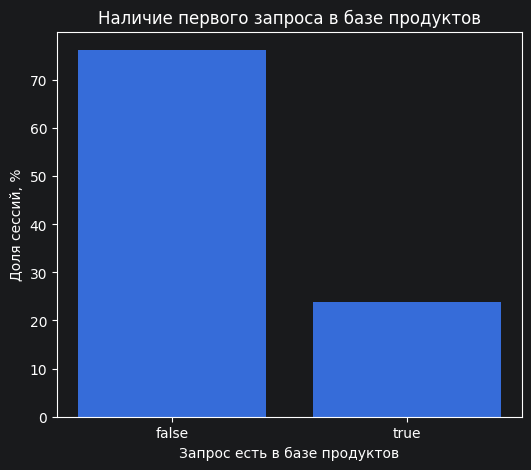

In [13]:
plt.figure(figsize=(6, 5))

plt.bar(
    counts_product_base["is_in_product_base"].cast(pl.Utf8).to_list(),
    counts_product_base["percent"].to_list()
)

plt.xlabel("Запрос есть в базе продуктов")
plt.ylabel("Доля сессий, %")
plt.title("Наличие первого запроса в базе продуктов")

plt.show()

### Вывод по признаку `is_in_product_base`

Около 23.8% первых поисковых запросов совпадают с одним из текстовых значений из базы продуктов: `name`, `brand`, `type` или `category_name`.

При этом около 76.2% запросов не имеют точного совпадения с этими полями. Это ожидаемо, потому что пользовательские запросы часто отличаются от карточек товаров: могут быть короче, содержать опечатки, неполные названия, дополнительные характеристики или разговорные формулировки.

Важно: здесь проверяется именно точное совпадение нормализованного запроса с нормализованным текстовым полем продукта, а не поиск подстроки или семантическое совпадение.

## Гистограмма запрос = артикул товара

In [14]:
# Создаём таблицу артикулов товаров.
# item_id приводим к строке, чтобы можно было сравнить с текстом запроса.

product_articles = (
    products
    .select(
        pl.col("item_id")
        .cast(pl.Utf8)
        .str.strip_chars()
        .alias("query_clean")
    )
    .filter(
        pl.col("query_clean").is_not_null() &
        (pl.col("query_clean") != "")
    )
    .unique()
)

Добавляю флаг is_article

In [15]:
if "is_article" in df.columns:
    df = df.drop("is_article")
df = (
    df
    .join(
        product_articles.with_columns(
            pl.lit(True).alias("is_article")
        ),
        on="query_clean",
        how="left"
    )
    .with_columns(
        pl.col("is_article").fill_null(False)
    )
)

считаю true/false

In [16]:
counts_article = (
    df
    .group_by("is_article")
    .len()
    .sort("is_article")
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100).alias("percent")
    )
)

counts_article

is_article,len,percent
bool,u32,f64
false,9031042,99.995438
true,412,0.004562


Гистограмма

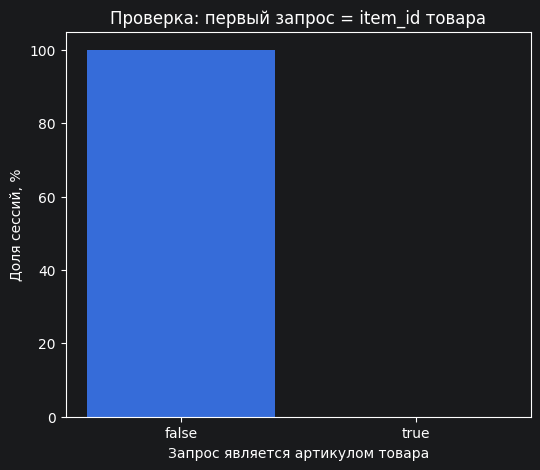

In [17]:
plt.figure(figsize=(6, 5))

plt.bar(
    counts_article["is_article"].cast(pl.Utf8).to_list(),
    counts_article["percent"].to_list()
)

plt.xlabel("Запрос является артикулом товара")
plt.ylabel("Доля сессий, %")
plt.title("Проверка: первый запрос = item_id товара")

plt.show()

### Вывод по признаку `is_article`

Почти все первые поисковые запросы не являются артикулом товара: доля `False` составляет около 99.995%.

Только 412 сессий имеют первый запрос, который точно совпадает с `item_id` товара. Это около 0.0046% всех сессий.

Значит, поиск по артикулу встречается крайне редко. Основная масса пользователей вводит обычные текстовые запросы: название товара, категорию, бренд или описание.

### Вывод по пункту 1.1

In [18]:
summary = pl.DataFrame({
    "feature": [
        "n_unique_queries",
        "query_len_words",
        "is_in_product_base",
        "is_article"
    ],
    "description": [
        "Количество уникальных поисковых запросов в сессии",
        "Длина первого поискового запроса в словах",
        "Совпадает ли первый запрос с текстом из базы продуктов",
        "Совпадает ли первый запрос с item_id товара"
    ]
})

summary

feature,description
str,str
"""n_unique_queries""","""Количество уникальных поисковы…"
"""query_len_words""","""Длина первого поискового запро…"
"""is_in_product_base""","""Совпадает ли первый запрос с т…"
"""is_article""","""Совпадает ли первый запрос с i…"



В большинстве интент-сессий пользователь делает небольшое число уникальных поисковых запросов: чаще всего 1–2 запроса. Это говорит о том, что большинство поисковых сценариев короткие.

Первые поисковые запросы также обычно короткие: чаще всего они состоят из 1–2 слов. Это соответствует типичному поведению на маркетплейсе, где пользователь вводит название товара, категорию, бренд или короткое описание.

Около 23.8% первых запросов имеют точное совпадение с одним из текстовых полей базы продуктов (`name`, `brand`, `type`, `category_name`). Остальные запросы не совпадают точно, что нормально: пользовательские формулировки могут быть короче, содержать опечатки, дополнительные характеристики или отличаться от карточек товаров.

Поиск по артикулу встречается крайне редко: только 412 сессий, то есть около 0.0046%, имеют первый запрос, точно совпадающий с `item_id` товара.

### Сохраняю все полученные данные в таблицу

In [19]:
OUTPUT = Path('../../data/intent_sessions_with_query_features.parquet')

df.write_parquet(OUTPUT)

Пример вывода данных

In [20]:
df.select([
    "user_id",
    "session_idx",
    "first_query",
    "n_unique_queries",
    "query_len_words",
    "is_in_product_base",
    "is_article"
]).head(20)

user_id,session_idx,first_query,n_unique_queries,query_len_words,is_in_product_base,is_article
i32,i32,str,u32,u32,bool,bool
1247576,1,"""салфетки бумажные""",2,2,true,false
6376393,2,"""багет с чесноком""",3,3,false,false
9372694,1,"""чеснок свежий""",1,2,false,false
6221232,2,"""камера заднего вида на форд тр…",2,6,false,false
6807379,3,"""зарядка для iphone""",1,3,false,false
…,…,…,…,…,…,…
9056695,1,"""xiaomi лампа настольная""",1,3,false,false
1500478,1,"""главная страница""",1,2,false,false
1936346,1,"""вазон напоьный камень""",4,3,false,false


## 1.2 Проверка наличия позиции первого клика

In [21]:
#все колонки датасета
for i, col in enumerate(df.columns, start=1):
    print(i, col)

1 user_id
2 session_idx
3 ts_start
4 ts_end
5 n_events
6 n_search
7 n_view
8 n_click
9 n_cart
10 n_fav
11 n_unique_queries
12 first_query
13 first_widget
14 n_unique_categories
15 top_category_in_session
16 duration_s
17 reached_cart
18 ts_first_cart
19 time_to_cart_s
20 query_clean
21 query_len_words
22 is_in_product_base
23 is_article


### Вывод по пункту 1.2

В текущем датасете отсутствует колонка с позицией первого клика.

Из признаков, связанных с кликами, есть только `n_click` — количество кликов в сессии. Этот признак не позволяет определить, на какой позиции поисковой выдачи был первый клик.

Следовательно, проанализировать позицию первого клика аналогично пункту 1.1 невозможно по текущему агрегированному датасету. Для такого анализа нужны event-level данные, где для каждого события клика хранится позиция товара в выдаче.

## 1.3 Функция query_stratification

`query_stratification_score` интерпретируется как скор сложности поисковой сессии: чем выше значение, тем больше признаков того, что пользователю было сложнее найти нужный товар.

Небольшое напоминание о полученных данных

n_unique_queries — чем больше, тем сложнее сессия

query_len_words — длинные запросы реже, могут быть более специфичными

is_in_product_base — если запрос есть в базе продуктов, он более понятный

is_article — если запрос является артикулом, это отдельный простой точный сценарий

также есть n_click, n_view, n_cart, reached_cart, duration_s, time_to_cart_s, то есть можно учитывать не только запрос, но и поведение в сессии

### Как можно определить смысл score
0 — очень простой / точный запрос

1 — простой запрос

2 — обычная сессия

3 — есть признаки усложнения

4 — сложная поисковая сессия

5 — очень сложная / проблемная сессия

## Логика score
+баллы за большое n_unique_queries (много уникальных запросов → пользователь переформулировал интент)

+баллы за длинный запрос (длинный запрос → более сложная или специфичная потребность)

+баллы если запроса нет в базе продуктов (запроса нет в базе → хуже совпадение с товарным словарём)

+баллы если нет кликов (нет кликов → поиск мог быть нерелевантным)

+баллы если не дошёл до корзины (нет корзины → интент не завершился покупочным действием)

-баллы если запрос = артикул (артикул → пользователь точно знает товар)

-баллы если запрос есть в базе продуктов


In [22]:
df = df.with_columns(
    (
        # n_unique_queries score
        pl.when(pl.col("n_unique_queries") <= 1).then(0)
        .when(pl.col("n_unique_queries") <= 3).then(1)
        .when(pl.col("n_unique_queries") <= 7).then(2)
        .when(pl.col("n_unique_queries") <= 19).then(3)
        .otherwise(4)
        +
        # query_len_words score
        pl.when(pl.col("query_len_words") <= 2).then(0)
        .when(pl.col("query_len_words") <= 4).then(1)
        .when(pl.col("query_len_words") <= 6).then(2)
        .otherwise(3)
        +
        # если запроса нет в базе продуктов
        pl.when(~pl.col("is_in_product_base")).then(1).otherwise(0)
        +
        # если не было кликов
        pl.when(pl.col("n_click") == 0).then(1).otherwise(0)
        +
        # если не дошёл до корзины
        pl.when(~pl.col("reached_cart")).then(1).otherwise(0)
        -
        # если запрос является артикулом
        pl.when(pl.col("is_article")).then(2).otherwise(0)
    )
    .clip(0, 5)
    .cast(pl.Int8)
    .alias("query_stratification_score")
)

### Распределение score

In [23]:
score_counts = (
    df
    .group_by("query_stratification_score")
    .len()
    .sort("query_stratification_score")
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100).alias("percent")
    )
)

score_counts

query_stratification_score,len,percent
i8,u32,f64
0,106544,1.179699
1,674437,7.467646
2,1887371,20.897754
3,2940167,32.554747
4,2294791,25.408877
5,1128144,12.491278


### График

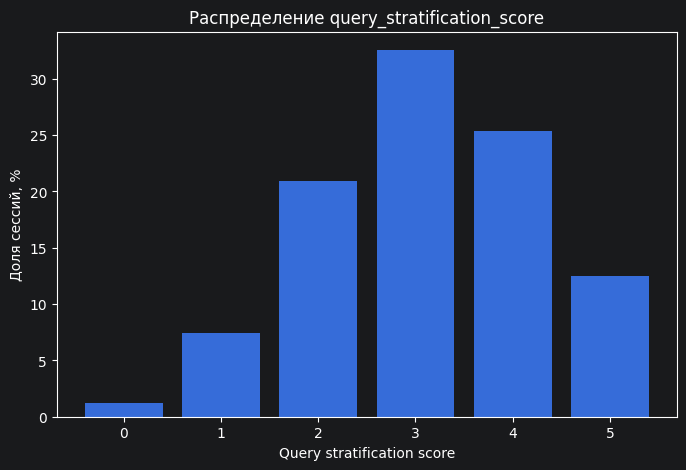

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    score_counts["query_stratification_score"].to_list(),
    score_counts["percent"].to_list()
)

plt.xlabel("Query stratification score")
plt.ylabel("Доля сессий, %")
plt.title("Распределение query_stratification_score")
plt.xticks(range(0, 6))

plt.show()

### Вывод по `query_stratification_score`

Полученный скор распределён по всему диапазону от 0 до 5, значит функция стратификации не вырождается в одно значение.

Наиболее частое значение — `3`. Также большую долю занимают значения `2` и `4`. Это означает, что основная масса сессий относится к среднему уровню сложности поиска.

Значения `0–1` встречаются редко: это наиболее простые или точные поисковые сценарии. Значение `5` соответствует наиболее сложным или потенциально проблемным сессиям, где одновременно проявляется несколько признаков сложности: много уникальных запросов, длинный запрос, отсутствие совпадения с базой продуктов, отсутствие кликов или недостижение корзины.

### сохраняю все в новый датасет

In [25]:
df.write_parquet(OUTPUT)


In [26]:
print(df.columns)

['user_id', 'session_idx', 'ts_start', 'ts_end', 'n_events', 'n_search', 'n_view', 'n_click', 'n_cart', 'n_fav', 'n_unique_queries', 'first_query', 'first_widget', 'n_unique_categories', 'top_category_in_session', 'duration_s', 'reached_cart', 'ts_first_cart', 'time_to_cart_s', 'query_clean', 'query_len_words', 'is_in_product_base', 'is_article', 'query_stratification_score']


### Корреляция с n_cart и с reached_cart

считаю query_stratification_score с n_cart и с reached_cart

In [28]:
df.select(
    pl.corr("query_stratification_score", "n_cart").alias("corr_score_n_cart"),
    pl.corr("query_stratification_score", "reached_cart").alias("corr_score_reached_cart"),
)

corr_score_n_cart,corr_score_reached_cart
f64,f64
0.061447,-0.242036


Смотрю средний n_cart по каждому score

mean_n_cart — среднее количество добавлений в корзину

cart_rate — доля сессий, где пользователь дошёл до корзины

In [29]:
cart_by_score = (
    df
    .group_by("query_stratification_score")
    .agg(
        pl.len().alias("n_sessions"),
        pl.col("n_cart").mean().alias("mean_n_cart"),
        pl.col("reached_cart").mean().alias("cart_rate")
    )
    .sort("query_stratification_score")
)

cart_by_score

query_stratification_score,n_sessions,mean_n_cart,cart_rate
i8,u32,f64,f64
0,106544,1.698031,0.99984
1,674437,1.442437,0.774413
2,1887371,1.430829,0.580776
3,2940167,1.73636,0.448144
4,2294791,2.338402,0.399016
5,1128144,2.820313,0.332731


График cart_rate по score

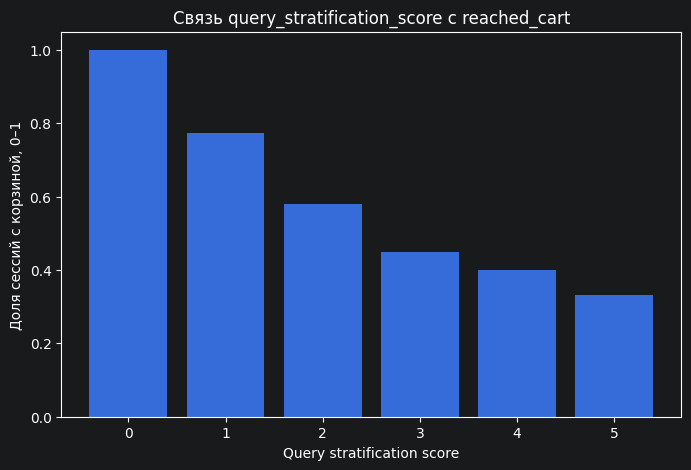

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    cart_by_score["query_stratification_score"].to_list(),
    cart_by_score["cart_rate"].to_list()
)

plt.xlabel("Query stratification score")
plt.ylabel("Доля сессий с корзиной, 0–1")
plt.title("Связь query_stratification_score с reached_cart")
plt.xticks(range(0, 6))

plt.show()

### Вывод по связи `query_stratification_score` с корзиной

По графику видно, что при росте `query_stratification_score` доля сессий с достижением корзины (`reached_cart`) последовательно снижается.

Для score `0` почти все сессии доходят до корзины, а для score `5` доля таких сессий падает примерно до 33%. Это подтверждает выбранную интерпретацию score: чем выше значение, тем сложнее или проблемнее была поисковая сессия.

Корреляция с `reached_cart` равна примерно `-0.242`, то есть связь отрицательная: при увеличении score вероятность достижения корзины уменьшается.

При этом корреляция с `n_cart` равна примерно `0.061`, то есть связь с количеством добавлений в корзину почти отсутствует. Поэтому для оценки качества стратификации более информативен именно признак `reached_cart`, а не счётчик `n_cart`.